# TinyChirp SincNet-Time TensorFlow

Train a 1D CNN with a SincNet-style learnable frontend directly on raw audio waveforms, export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are later baked into a standard `Conv1D` layer for inference.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from typing import TYPE_CHECKING
import sys
import tensorflow as tf

from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from building_tensorflow.utils import (  # noqa: E402
    SAMPLE_RATE,
    FRAME_LENGTH,
    FRAME_STEP,
    TARGET_FRAMES_TIME,
    TARGET_AUDIO_LEN_TIME,
    DATASET_ROOT,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
    build_representative_batches,
    export_keras_model_to_int8_tflite,
    collect_test_clips_for_rs,
    write_audio_sample_rs,
)

configure_tf_runtime()
set_global_seed()

paths = get_paths("sincnet_time_tf")
OUT_TFLITE = paths.out_tflite
OUT_AUDIO_RS = paths.out_audio_rs

print("Dataset root:", DATASET_ROOT)
print("Model output:", OUT_TFLITE)
print("Audio sample output:", OUT_AUDIO_RS)
print("Sample rate:", SAMPLE_RATE)
print("Frame length:", FRAME_LENGTH)
print("Frame step:", FRAME_STEP)
print("Target frames (time):", TARGET_FRAMES_TIME)
print("Target audio length (time):", TARGET_AUDIO_LEN_TIME)

2026-04-10 16:14:57.798224: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 16:14:57.809731: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-10 16:14:57.826620: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-10 16:14:57.826672: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-10 16:14:57.838389: I tensorflow/core/platform/cpu_feature_gua

Dataset root: /home/nathan/Documents/tiny-chirp-microflow/dataset
Model output: /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_tf.tflite
Audio sample output: /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs
Sample rate: 16000
Frame length: 1024
Frame step: 256
Target frames (time): 184
Target audio length (time): 47872


2026-04-10 16:15:01.579476: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-10 16:15:01.610343: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-10 16:15:01.611453: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [3]:
train_ds, val_ds, test_ds, label_names = make_time_datasets()
num_labels = len(label_names)
print("Classes:", label_names)
print(len(train_ds),len(val_ds),len(test_ds))

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.


2026-04-10 16:15:02.688476: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']
353 44 44


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a 1D convolution.

In [4]:
import tensorflow as tf
import numpy as np
from building_tensorflow.utils import get_flops_native


class CustomFrontend(tf.keras.layers.Layer):
    def __init__(self, num_filters: int, kernel_size: int, stride: int, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride
        self.params = self.add_weight(
            shape=(kernel_size, 1, num_filters),
            initializer="random_normal",
            trainable=True,
            name="sinc_params",
        )

    def get_filters(self) -> tf.Tensor:
        return tf.math.sin(self.params)

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        return tf.nn.conv1d(inputs, self.get_filters(), stride=self.stride, padding="VALID")

In [5]:
NUM_FILTERS = 40
DENSE_HIDDEN = 64
KERNEL_SIZE = 64
STRIDE = 8
def build_training_model(num_labels: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
    x = CustomFrontend(
        num_filters=NUM_FILTERS, 
        kernel_size=KERNEL_SIZE, 
        stride=STRIDE, 
        name="sinc_frontend")(inputs)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_labels, activation=None)(x)
    return tf.keras.Model(inputs, outputs, name="sincnet_time_training")


training_model = build_training_model(num_labels)
training_model.summary()
flops = get_flops_native(training_model, batch_size=1)
print(f"Total FLOPs: {flops}")

Model: "sincnet_time_training"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 47872, 1)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sinc_frontend (CustomFrontend)  │ (None, 5977, 40)       │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 5977, 40)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 40)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,314 (20.76 KB)

 Trainable params: 5,314 (20.76 KB)

 Non-trainable params: 0 (0.00 B)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
Total FLOPs: 30846762


/home/nathan/Documents/tiny-chirp-microflow/building_tensorflow/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 47872, 1))']
  warnings.warn(msg)
2026-04-10 16:15:03.652390: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-10 16:15:03.653655: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2026-04-10 16:15:03.653730: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-04-10 16:15:03.654013: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUM

In [6]:
import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

training_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

wandb.init(
    # set the wandb project where this run will be logged
    name="sincnet",
    project="tinychirp",

    # track hyperparameters and run metadata with wandb.config
    config={
        "num_filters": NUM_FILTERS,
        "kernel_size": KERNEL_SIZE,
        "stride": STRIDE,
        "dense_hidden": DENSE_HIDDEN,
    }
)


history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    validation_steps=44,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
        ),
        WandbMetricsLogger(log_freq=5),
        WandbModelCheckpoint("models.keras")
    ],
)
wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.
wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/50


I0000 00:00:1775830507.153855  178728 service.cc:145] XLA service 0x7e7dd4014f60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775830507.153911  178728 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-10 16:15:07.194128: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-10 16:15:07.347306: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 16/353 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5916 - loss: 0.6891

I0000 00:00:1775830510.207037  178728 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step - accuracy: 0.7790 - loss: 0.4532 - val_accuracy: 0.9290 - val_loss: 0.2646
Epoch 2/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.9162 - loss: 0.2527 - val_accuracy: 0.9319 - val_loss: 0.2051
Epoch 3/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9276 - loss: 0.2176 - val_accuracy: 0.9413 - val_loss: 0.1728
Epoch 4/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9392 - loss: 0.1914 - val_accuracy: 0.9536 - val_loss: 0.1489
Epoch 5/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.9459 - loss: 0.1736 - val_accuracy: 0.9572 - val_loss: 0.1372
Epoch 6/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.9500 - loss: 0.1592 - val_accuracy: 0.9580 - val_loss: 0.1256
Epoch 7/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.9519 - loss: 0.1470 - val_accuracy: 0.9616 - val_loss: 0.1151
Epoch 8/50
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9520 - loss: 0.1385 - val_accurac

batch/accuracy,▁▂▆▆▆▇▇▇▇▇▇▇██▇█████████████████████████
batch/batch_step,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▄▃▃▃▂▂▂▂▁▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,▁▆▆▇▇▇▇▇▇▇▇█████████████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▁▃▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇█▇▇▇█▇█▇▇██▇█▇██▇█████
epoch/val_loss,█▆▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/accuracy,0.97133


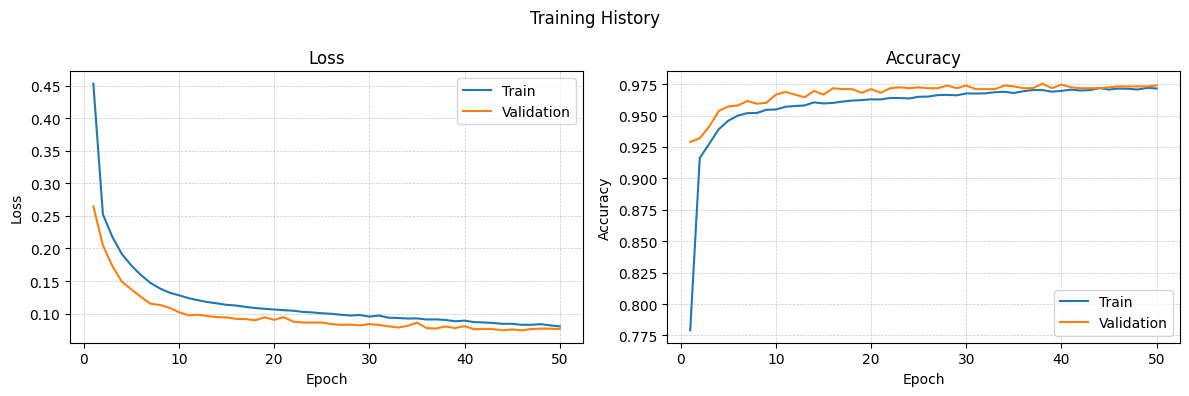

In [7]:
from building_tensorflow.utils import plot_training_history
plot_training_history(history)

353it [00:20, 17.12it/s]2026-04-10 16:35:20.322024: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
353it [00:20, 17.03it/s]
42it [00:02, 16.88it/s]2026-04-10 16:35:23.107682: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
44it [00:02, 18.04it/s]


=== Binary classifier metrics : TEST SET===
Threshold: 0.2417  (best F2 threshold)
Accuracy : 0.9627
Precision: 0.9028
Recall   : 0.9934
F2 score : 0.9739
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9955


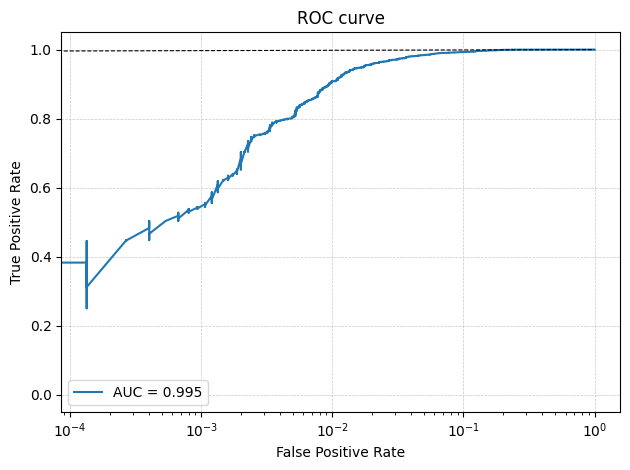

In [8]:
from building_tensorflow.utils import evaluate_binary_classifier, display_eval_metrics
train_metrics, test_metrics = evaluate_binary_classifier(training_model,
 train_ds,
 test_ds,
  threshold=0.5,)
display_eval_metrics(train_metrics, test_metrics)

## Make frontend filters into a Conv1D inference model


In [9]:
# Extract the trained custom frontend and bake its filters
custom_layer = None
for layer in training_model.layers:
    if isinstance(layer, CustomFrontend):
        custom_layer = layer
        break

if custom_layer is None:
    raise RuntimeError("CustomFrontend layer not found in training_model")

baked_filters = custom_layer.get_filters().numpy()

# Build Conv1D-based inference model
infer_inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1))
x = tf.keras.layers.Conv1D(
    filters=NUM_FILTERS,
    kernel_size=KERNEL_SIZE,
    strides=STRIDE,
    padding="valid",
    use_bias=False,
    name="baked_conv",
)(infer_inputs)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = tf.keras.layers.Dense(64, activation="relu", name="dense_hidden")(x)
infer_outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)

inference_model = tf.keras.Model(infer_inputs, infer_outputs, name="sincnet_time_inference")

# Copy weights
inference_model.get_layer("baked_conv").set_weights([baked_filters])
inference_model.get_layer("dense_hidden").set_weights(
    training_model.layers[-2].get_weights()
)
inference_model.get_layer("dense_logits").set_weights(
    training_model.layers[-1].get_weights()
)

# Optional parity check on a small batch
for batch_audio, _ in test_ds.take(1):
    batch_audio_np = batch_audio.numpy()
    logits_train = training_model.predict(batch_audio_np, verbose=0)
    logits_infer = inference_model.predict(batch_audio_np, verbose=0)
    print("Max abs diff between training and inference logits:", np.max(np.abs(logits_train - logits_infer)))

Max abs diff between training and inference logits: 92.59918


2026-04-10 16:35:24.511434: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Export quantized TFLite model and Rust audio samples

We now export an int8-quantized TFLite model using the shared helpers from `building_tensorflow.utils`, and regenerate `audio_sample.rs` clips for the TinyChirp Rust runner.

In [10]:
# Build representative batches for post-training quantization
rep_batches = build_representative_batches(
    test_ds,
    target_len=TARGET_AUDIO_LEN_TIME,
    take=100,
)

# Export int8 TFLite model
try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

# Collect test clips and write Rust audio_sample.rs
clips = collect_test_clips_for_rs(
    DATASET_ROOT / "testing",
    sample_rate=SAMPLE_RATE,
    target_len=TARGET_AUDIO_LEN_TIME,
    num_per_label=2,
)

write_audio_sample_rs(
    OUT_AUDIO_RS,
    clips,
    SAMPLE_RATE,
    generator_name="building_tensorflow/sincnet_time.ipynb",
)

print(
    "Wrote",
    OUT_AUDIO_RS,
    "clips=",
    len(clips),
    "samples_per_clip=",
    len(clips[0][1]),
)

2026-04-10 16:35:24.908961: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


INFO:tensorflow:Assets written to: temp_saved_model/assets


INFO:tensorflow:Assets written to: temp_saved_model/assets


Saved artifact at 'temp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 47872, 1), dtype=tf.float32, name='keras_tensor_6')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139072007882704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139072007882352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139072007881824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139072007881296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139072007880944: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1775831725.163841  178565 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1775831725.163864  178565 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-10 16:35:25.164203: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: temp_saved_model
2026-04-10 16:35:25.164642: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-10 16:35:25.164653: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: temp_saved_model
2026-04-10 16:35:25.169208: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-10 16:35:25.169732: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-10 16:35:25.191519: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: temp_saved_model
2026-04-10 16:35:25.197492: I tensorflow/cc/saved_model/loader.cc

Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_time_tf.tflite
Found 1393 files belonging to 2 classes.


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Wrote /home/nathan/Documents/tiny-chirp-microflow/src/audio_sample.rs clips= 4 samples_per_clip= 47872
